# Task 3 — Temporal Regression Models
**NYC Yellow Taxi | 2023–2025**

- **Primary target**: `trip_count` (daily demand)
- **Secondary target**: `total_revenue` (daily revenue)

Models: SARIMA · SARIMAX+CBD · Auto-ARIMA · OLS Regression

In [2]:
# CELL 1 — Imports and global settings

!pip install pmdarima holidays --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm
import holidays

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

SEED = 42
np.random.seed(SEED)

# Target variable config — swap TARGET to "total_revenue" for secondary analysis
TARGETS = {
    "trip_count":    {"label": "Daily Trip Count",       "color": "#2563EB", "unit": "Trips"},
    "total_revenue": {"label": "Daily Total Revenue",    "color": "#9333EA", "unit": "USD"},
}

CBD_DATE = pd.Timestamp("2025-01-05")   # NYC congestion pricing structural break

print("All libraries loaded.")
print(f"Targets: {list(TARGETS.keys())}")

All libraries loaded.
Targets: ['trip_count', 'total_revenue']


In [3]:
# CELL 2 — Load data from Task 1 outputs

train_df   = pd.read_csv("/content/yellow_taxi_train.csv",
                         index_col="date", parse_dates=True)
holdout_df = pd.read_csv("/content/yellow_taxi_holdout.csv",
                         index_col="date", parse_dates=True)
daily      = pd.read_csv("/content/yellow_taxi_daily.csv",
                         index_col="date", parse_dates=True)

print(f"Train  : {train_df.index[0].date()} → {train_df.index[-1].date()} ({len(train_df)} days)")
print(f"Test   : {holdout_df.index[0].date()} → {holdout_df.index[-1].date()} ({len(holdout_df)} days)")
print(f"\nColumns available: {list(daily.columns)}")
print(f"\nTrain stats:\n{train_df[list(TARGETS.keys())].describe().round(2)}")

Train  : 2023-01-01 → 2025-09-30 (1004 days)
Test   : 2025-10-01 → 2025-11-30 (61 days)

Columns available: ['trip_count', 'avg_fare', 'total_revenue']

Train stats:
       trip_count  total_revenue
count     1004.00        1004.00
mean    111632.62     3210435.16
std      19696.93      575705.99
min      18091.00      458606.79
25%      98923.25     2811770.37
50%     111857.50     3206789.48
75%     125642.25     3588425.61
max     166360.00     4931679.44


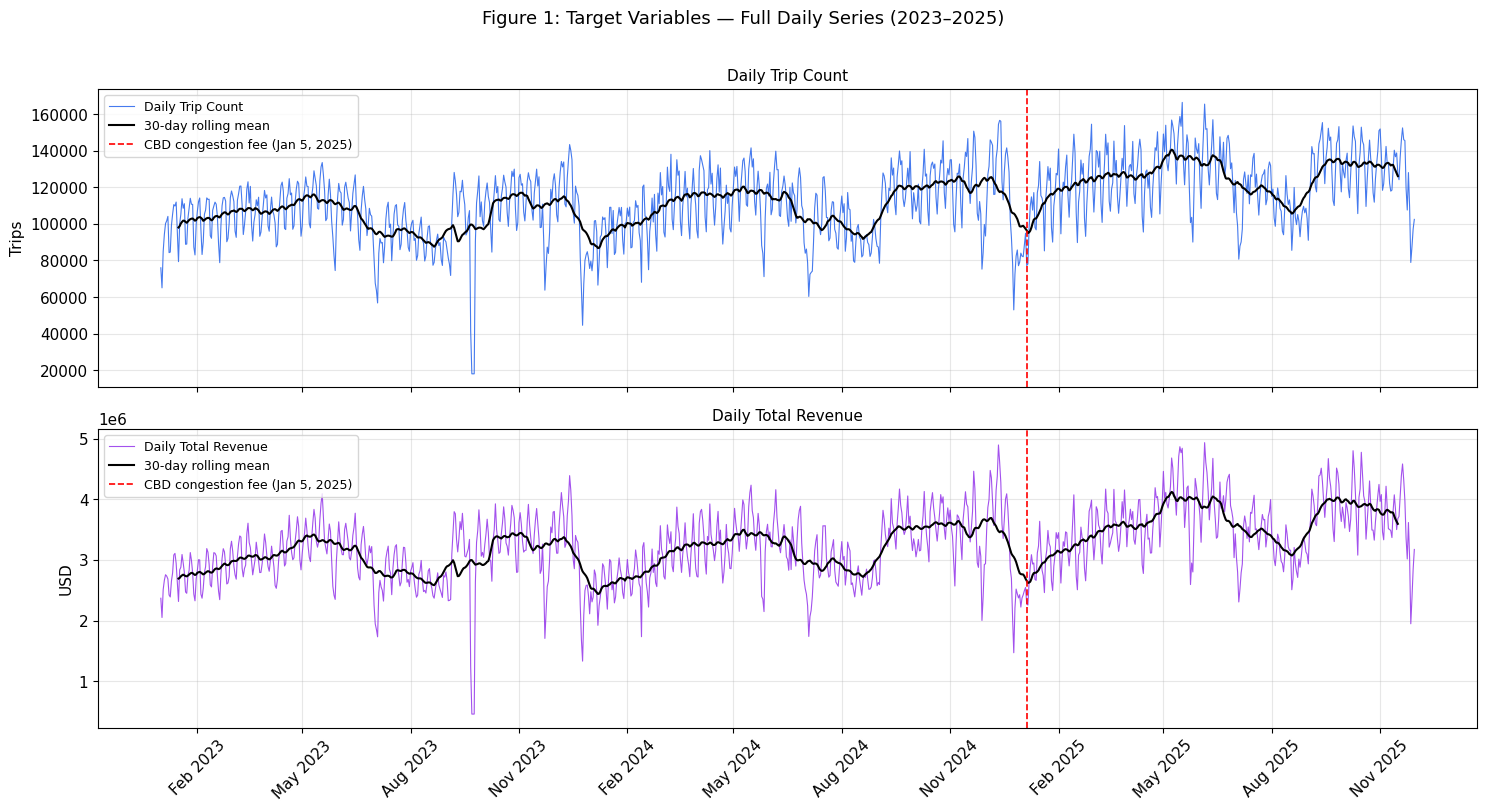

Saved: t3_fig1_series_overview.png


In [4]:
# CELL 3 — Series overview (both targets)

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle("Figure 1: Target Variables — Full Daily Series (2023–2025)",
             fontsize=13, y=1.01)

for ax, (col, meta) in zip(axes, TARGETS.items()):
    s = daily[col]
    ax.plot(s.index, s, color=meta["color"], linewidth=0.8, alpha=0.85,
            label=meta["label"])
    ax.plot(s.index, s.rolling(30, center=True).mean(),
            color="black", linewidth=1.5, label="30-day rolling mean")
    ax.axvline(CBD_DATE, color="red", linestyle="--", linewidth=1.2,
               label="CBD congestion fee (Jan 5, 2025)")
    ax.set_ylabel(meta["unit"])
    ax.set_title(meta["label"], fontsize=11)
    ax.legend(fontsize=9, loc="upper left")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/t3_fig1_series_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig1_series_overview.png")

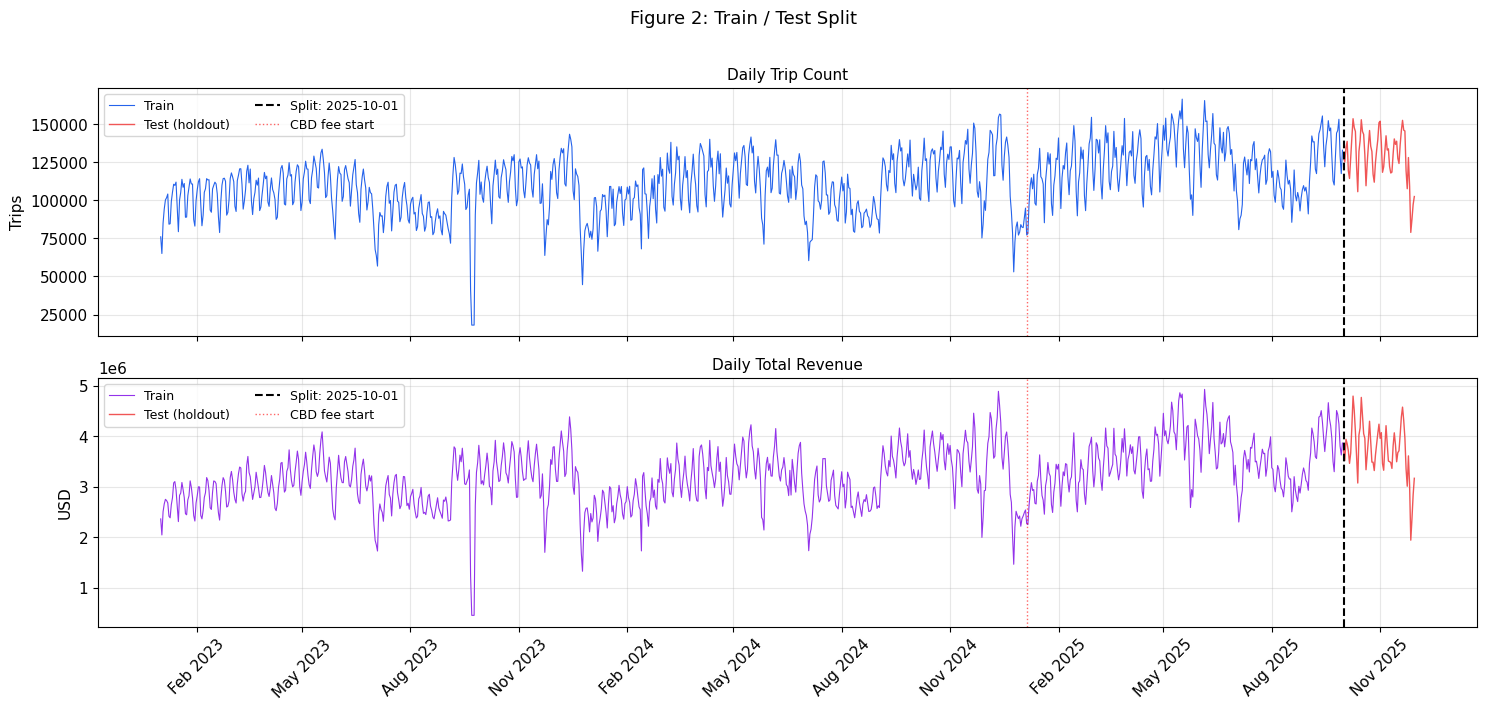

Saved: t3_fig2_train_test_split.png


In [5]:
# CELL 4 — Train / test split confirmation

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle("Figure 2: Train / Test Split", fontsize=13, y=1.01)

for ax, (col, meta) in zip(axes, TARGETS.items()):
    ax.plot(train_df.index,   train_df[col],   color=meta["color"],
            linewidth=0.8, label="Train")
    ax.plot(holdout_df.index, holdout_df[col], color="#EF4444",
            linewidth=1.0, label="Test (holdout)", alpha=0.9)
    ax.axvline(holdout_df.index[0], color="black", linestyle="--",
               linewidth=1.5, label=f"Split: {holdout_df.index[0].date()}")
    ax.axvline(CBD_DATE, color="red", linestyle=":", linewidth=1.0,
               alpha=0.6, label="CBD fee start")
    ax.set_ylabel(meta["unit"])
    ax.set_title(meta["label"], fontsize=11)
    ax.legend(fontsize=9, ncol=2)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/content/t3_fig2_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig2_train_test_split.png")

In [6]:
# CELL 5 — Shared helper functions

NY_HOLIDAYS = holidays.US(state="NY", years=range(2023, 2026))

def make_cbd_exog(index):
    """Binary exogenous column: 1 on/after Jan 5 2025, else 0."""
    return pd.DataFrame(
        {"cbd_fee": (index >= CBD_DATE).astype(int)},
        index=index,
    )

def evaluate(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    print(f"  {model_name:40s} | MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")
    return {"Model": model_name, "MAE": round(mae, 3),
            "RMSE": round(rmse, 3), "MAPE": round(mape, 2)}

def build_ols_features(dates, history_series):
    """Build OLS feature matrix for given dates using history_series for lags."""
    rows = []
    for dt in dates:
        lag1 = history_series.get(dt - pd.Timedelta(days=1), np.nan)
        lag7 = history_series.get(dt - pd.Timedelta(days=7), np.nan)
        rows.append({
            "dow":     dt.dayofweek,
            "month":   dt.month,
            "trend":   (dt - pd.Timestamp("2023-01-01")).days,
            "cbd":     int(dt >= CBD_DATE),
            "holiday": int(dt in NY_HOLIDAYS),
            "lag1":    lag1,
            "lag7":    lag7,
        })
    df = pd.DataFrame(rows, index=dates)
    dow_dummies   = pd.get_dummies(df["dow"],   prefix="dow",   drop_first=True)
    month_dummies = pd.get_dummies(df["month"], prefix="month", drop_first=True)
    features = pd.concat(
        [df[["trend", "cbd", "holiday", "lag1", "lag7"]],
         dow_dummies, month_dummies],
        axis=1
    ).astype(float)
    return features

print("Helper functions ready.")

Helper functions ready.


In [7]:
# CELL 6 — Modelling function (runs all 4 models for one target variable)

def run_all_models(col, train_series, test_series):
    """
    Fits SARIMA, SARIMAX+CBD, Auto-ARIMA, OLS on train_series,
    forecasts test_series, returns predictions dict and metrics list.
    """
    meta  = TARGETS[col]
    label = meta["label"]
    color = meta["color"]

    exog_train = make_cbd_exog(train_series.index)
    exog_test  = make_cbd_exog(test_series.index)

    preds   = {}
    cis     = {}
    metrics = []

    print(f"\n{'='*65}")
    print(f"  TARGET: {label}")
    print(f"{'='*65}")

    # ── Model 1: SARIMA(1,1,1)(1,1,1)[7] ────────────────────
    print("\n[1/4] SARIMA(1,1,1)(1,1,1)[7] ...")
    sarima_fit = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    fc = sarima_fit.get_forecast(steps=len(test_series))
    preds["SARIMA"]  = pd.Series(fc.predicted_mean.values, index=test_series.index)
    cis["SARIMA"]    = fc.conf_int(alpha=0.05).set_index(test_series.index)
    metrics.append(evaluate(test_series, preds["SARIMA"], "SARIMA(1,1,1)(1,1,1)[7]"))

    # Ljung-Box on residuals
    lb = acorr_ljungbox(sarima_fit.resid.dropna(), lags=[7, 14, 21], return_df=True)
    print("  Ljung-Box p-values (want > 0.05 = white noise):")
    print("  " + lb["lb_pvalue"].round(4).to_string())

    # ── Model 2: SARIMAX + CBD dummy ─────────────────────────
    print("\n[2/4] SARIMAX(1,1,1)(1,1,1)[7] + CBD dummy ...")
    sarimax_fit = SARIMAX(
        train_series,
        exog=exog_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    cbd_coef = sarimax_fit.params.get("cbd_fee", np.nan)
    cbd_pval = sarimax_fit.pvalues.get("cbd_fee", np.nan)
    print(f"  CBD coefficient: {cbd_coef:.4f}  (p={cbd_pval:.4f})")

    fc2 = sarimax_fit.get_forecast(steps=len(test_series), exog=exog_test)
    preds["SARIMAX"] = pd.Series(fc2.predicted_mean.values, index=test_series.index)
    cis["SARIMAX"]   = fc2.conf_int(alpha=0.05).set_index(test_series.index)
    metrics.append(evaluate(test_series, preds["SARIMAX"], "SARIMAX(1,1,1)(1,1,1)[7]+CBD"))

    # ── Model 3: Auto-ARIMA ──────────────────────────────────
    print("\n[3/4] Auto-ARIMA (AIC, m=7, d=1 fixed) ... [takes ~5-10 min]")
    auto_model = pm.auto_arima(
        train_series,
        X=exog_train.values,
        d=1, D=1,
        seasonal=True, m=7,
        start_p=0, max_p=3,
        start_q=0, max_q=3,
        start_P=0, max_P=2,
        start_Q=0, max_Q=2,
        stepwise=True,
        information_criterion="aic",
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
        random_state=SEED,
    )
    print(f"\n  Auto-ARIMA selected: {auto_model.order} x {auto_model.seasonal_order}")

    auto_vals, auto_ci = auto_model.predict(
        n_periods=len(test_series),
        X=exog_test.values,
        return_conf_int=True,
        alpha=0.05,
    )
    preds["AutoARIMA"] = pd.Series(auto_vals, index=test_series.index)
    cis["AutoARIMA"]   = pd.DataFrame(auto_ci, index=test_series.index,
                                      columns=["lower", "upper"])
    auto_label = f"Auto-ARIMA{auto_model.order}x{auto_model.seasonal_order[:-1]}"
    metrics.append(evaluate(test_series, preds["AutoARIMA"], auto_label))

    # ── Model 4: OLS Regression ──────────────────────────────
    print("\n[4/4] OLS Linear Regression ...")
    X_train = build_ols_features(train_series.index, train_series)
    valid   = X_train.dropna()
    y_valid = train_series.loc[valid.index]

    ols = LinearRegression()
    ols.fit(valid, y_valid)
    print(f"  Training R²: {ols.score(valid, y_valid):.4f}")

    # Recursive forecasting on test set
    history = train_series.copy()
    ols_preds = []
    for dt in test_series.index:
        feat = build_ols_features([dt], history)
        feat = feat.ffill().fillna(0)
        feat = feat.reindex(columns=valid.columns, fill_value=0)
        pred = ols.predict(feat)[0]
        ols_preds.append(pred)
        history[dt] = test_series[dt]   # teacher forcing

    preds["OLS"] = pd.Series(ols_preds, index=test_series.index)
    metrics.append(evaluate(test_series, preds["OLS"], "OLS Linear Regression"))

    return preds, cis, metrics, sarima_fit, auto_model, ols, valid.columns

In [8]:
# CELL 7 — Run models for PRIMARY target: trip_count

print("Running models for PRIMARY target: trip_count")

tc_train = train_df["trip_count"].copy()
tc_test  = holdout_df["trip_count"].copy()

tc_preds, tc_cis, tc_metrics, tc_sarima, tc_auto, tc_ols, tc_cols = \
    run_all_models("trip_count", tc_train, tc_test)

print("\n\nTrip Count — Model Comparison:")
tc_results = pd.DataFrame(tc_metrics).set_index("Model")
print(tc_results)

Running models for PRIMARY target: trip_count

  TARGET: Daily Trip Count

[1/4] SARIMA(1,1,1)(1,1,1)[7] ...
  SARIMA(1,1,1)(1,1,1)[7]                  | MAE=8699.130  RMSE=14313.452  MAPE=7.73%
  Ljung-Box p-values (want > 0.05 = white noise):
  7     0.0
14    0.0
21    0.0

[2/4] SARIMAX(1,1,1)(1,1,1)[7] + CBD dummy ...
  CBD coefficient: -3827.4999  (p=0.8793)
  SARIMAX(1,1,1)(1,1,1)[7]+CBD             | MAE=8731.278  RMSE=14389.773  MAPE=7.77%

[3/4] Auto-ARIMA (AIC, m=7, d=1 fixed) ... [takes ~5-10 min]
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=27367.771, Time=0.20 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=21263.708, Time=1.43 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=20955.797, Time=9.27 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=21481.842, Time=0.44 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=inf, Time=2.79 sec
 ARIMA(0,1,1)(0,1,2)[7]             : AIC=21077.323, Time=1.83 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=2126

In [9]:
# CELL 8 — Run models for SECONDARY target: total_revenue

print("Running models for SECONDARY target: total_revenue")

tr_train = train_df["total_revenue"].copy()
tr_test  = holdout_df["total_revenue"].copy()

tr_preds, tr_cis, tr_metrics, tr_sarima, tr_auto, tr_ols, tr_cols = \
    run_all_models("total_revenue", tr_train, tr_test)

print("\n\nTotal Revenue — Model Comparison:")
tr_results = pd.DataFrame(tr_metrics).set_index("Model")
print(tr_results)

Running models for SECONDARY target: total_revenue

  TARGET: Daily Total Revenue

[1/4] SARIMA(1,1,1)(1,1,1)[7] ...
  SARIMA(1,1,1)(1,1,1)[7]                  | MAE=692056.774  RMSE=892285.210  MAPE=21.24%
  Ljung-Box p-values (want > 0.05 = white noise):
  7     0.0002
14    0.0002
21    0.0013

[2/4] SARIMAX(1,1,1)(1,1,1)[7] + CBD dummy ...
  CBD coefficient: -100528.5950  (p=0.8473)
  SARIMAX(1,1,1)(1,1,1)[7]+CBD             | MAE=692011.205  RMSE=892201.295  MAPE=21.24%

[3/4] Auto-ARIMA (AIC, m=7, d=1 fixed) ... [takes ~5-10 min]
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=34128.621, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=28019.551, Time=0.58 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.76 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=28248.804, Time=0.15 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=27937.918, Time=1.09 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=2.63 sec
 ARIMA(1,1,0)(1,1,1)[7]  

In [10]:
# CELL 9 — Combined evaluation table (Table 1 for report)

print("\n")
print("=" * 70)
print("  TABLE 1: Model Performance on Test Set (Oct–Nov 2025)")
print("=" * 70)

tc_results["Target"] = "trip_count"
tr_results["Target"] = "total_revenue"

combined = pd.concat([tc_results, tr_results])
combined = combined[["Target", "MAE", "RMSE", "MAPE"]]
print(combined.to_string())

combined.to_csv("/content/task3_model_comparison.csv")
print("\nSaved: task3_model_comparison.csv")

for target, res in [("trip_count", tc_results), ("total_revenue", tr_results)]:
    best = res["RMSE"].idxmin()
    print(f"  Best RMSE for {target}: {best}")



  TABLE 1: Model Performance on Test Set (Oct–Nov 2025)
                                      Target         MAE         RMSE   MAPE
Model                                                                       
SARIMA(1,1,1)(1,1,1)[7]           trip_count    8699.130    14313.452   7.73
SARIMAX(1,1,1)(1,1,1)[7]+CBD      trip_count    8731.278    14389.773   7.77
Auto-ARIMA(0, 1, 1)x(0, 1, 1)     trip_count   13593.371    19716.120  12.10
OLS Linear Regression             trip_count   11285.905    13259.836   8.65
SARIMA(1,1,1)(1,1,1)[7]        total_revenue  692056.774   892285.210  21.24
SARIMAX(1,1,1)(1,1,1)[7]+CBD   total_revenue  692011.205   892201.295  21.24
Auto-ARIMA(0, 1, 0)x(2, 1, 0)  total_revenue  801184.660  1005103.393  24.29
OLS Linear Regression          total_revenue  329302.131   412028.472   8.84

Saved: task3_model_comparison.csv
  Best RMSE for trip_count: OLS Linear Regression
  Best RMSE for total_revenue: OLS Linear Regression


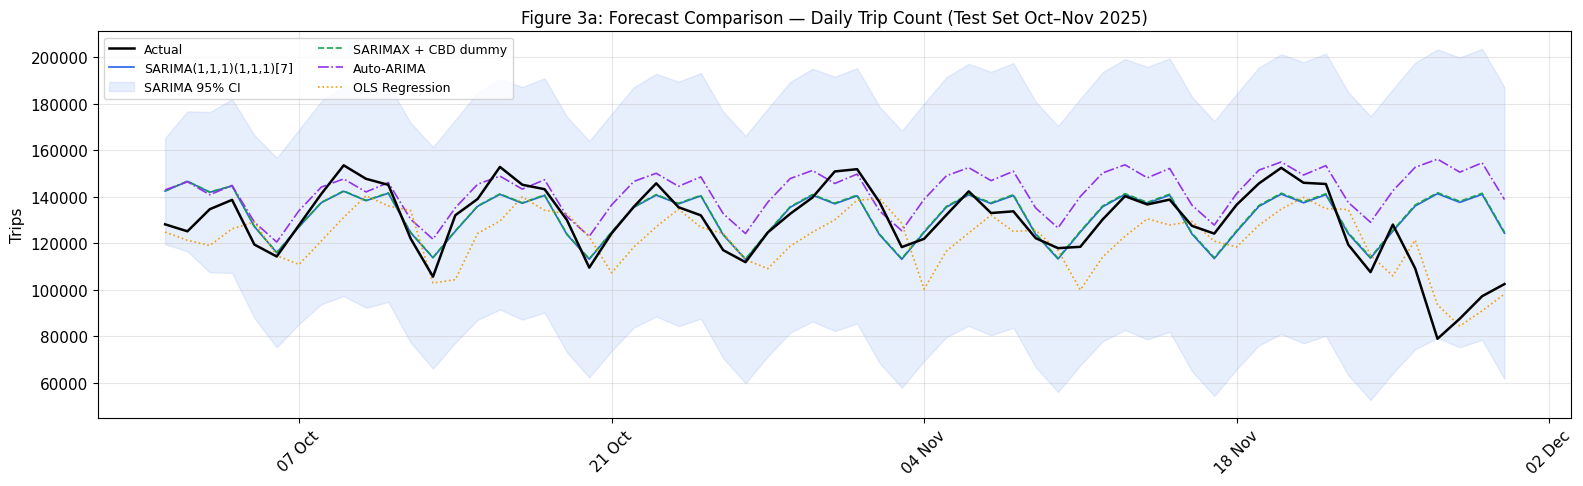

Saved: /content/t3_fig3_forecast_trip_count.png


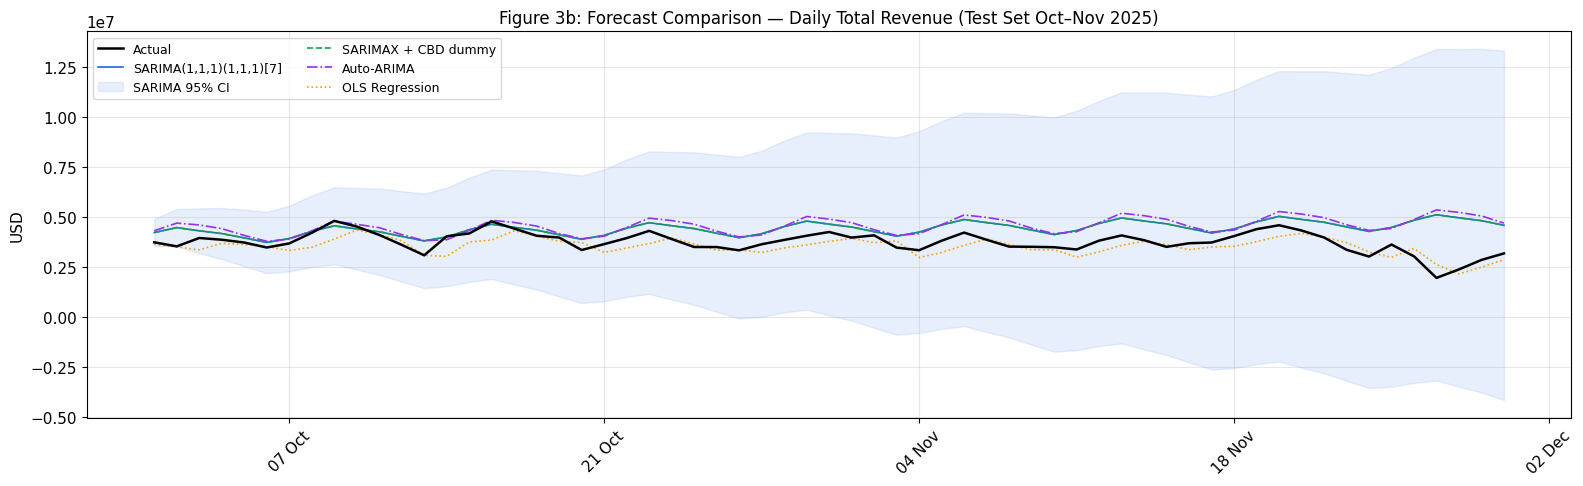

Saved: /content/t3_fig3_forecast_total_revenue.png


In [11]:
# CELL 10 — Figure 3: Forecast comparison plots (one per target)

for col, meta, test_s, preds, cis in [
    ("trip_count",    TARGETS["trip_count"],    tc_test, tc_preds, tc_cis),
    ("total_revenue", TARGETS["total_revenue"], tr_test, tr_preds, tr_cis),
]:
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(test_s.index, test_s, color="black", linewidth=1.8,
            zorder=5, label="Actual")

    ax.plot(test_s.index, preds["SARIMA"],    color="#2563EB", linewidth=1.2,
            linestyle="-",  label="SARIMA(1,1,1)(1,1,1)[7]")
    ax.fill_between(test_s.index,
                    cis["SARIMA"].iloc[:, 0], cis["SARIMA"].iloc[:, 1],
                    color="#2563EB", alpha=0.10, label="SARIMA 95% CI")

    ax.plot(test_s.index, preds["SARIMAX"],   color="#16A34A", linewidth=1.2,
            linestyle="--", label="SARIMAX + CBD dummy")

    ax.plot(test_s.index, preds["AutoARIMA"], color="#9333EA", linewidth=1.2,
            linestyle="-.", label="Auto-ARIMA")

    ax.plot(test_s.index, preds["OLS"],       color="#F59E0B", linewidth=1.2,
            linestyle=":",  label="OLS Regression")

    ax.set_title(
        f"Figure 3{'a' if col == 'trip_count' else 'b'}: Forecast Comparison — "
        f"{meta['label']} (Test Set Oct–Nov 2025)",
        fontsize=12
    )
    ax.set_ylabel(meta["unit"])
    ax.legend(fontsize=9, loc="upper left", ncol=2)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    plt.xticks(rotation=45)
    plt.tight_layout()

    fname = f"/content/t3_fig3_forecast_{col}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

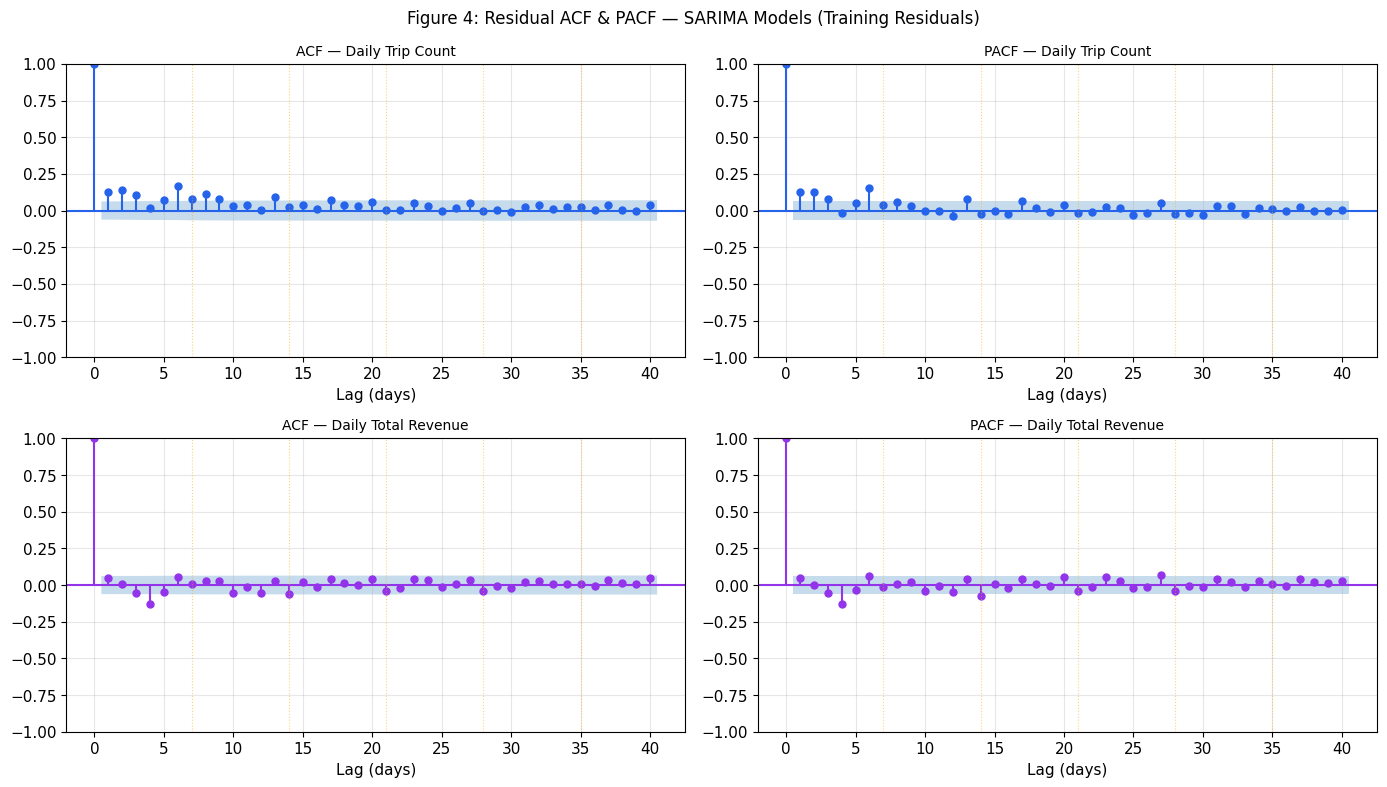

Saved: t3_fig4_residual_acf.png


In [12]:
# CELL 11 — Figure 4: Residual ACF (primary target SARIMA)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Figure 4: Residual ACF & PACF — SARIMA Models (Training Residuals)",
             fontsize=12)

for row, (col, meta, sarima_fit) in enumerate([
    ("trip_count",    TARGETS["trip_count"],    tc_sarima),
    ("total_revenue", TARGETS["total_revenue"], tr_sarima),
]):
    resid = sarima_fit.resid.dropna()
    plot_acf(resid,  lags=40, ax=axes[row][0], alpha=0.05,
             color=meta["color"], vlines_kwargs={"colors": meta["color"]})
    plot_pacf(resid, lags=40, ax=axes[row][1], alpha=0.05, method="ywmle",
              color=meta["color"], vlines_kwargs={"colors": meta["color"]})
    for lag in range(7, 41, 7):
        axes[row][0].axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.5)
        axes[row][1].axvline(lag, color="orange", linestyle=":", linewidth=0.8, alpha=0.5)
    axes[row][0].set_title(f"ACF — {meta['label']}", fontsize=10)
    axes[row][1].set_title(f"PACF — {meta['label']}", fontsize=10)
    axes[row][0].set_xlabel("Lag (days)")
    axes[row][1].set_xlabel("Lag (days)")

plt.tight_layout()
plt.savefig("/content/t3_fig4_residual_acf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig4_residual_acf.png")

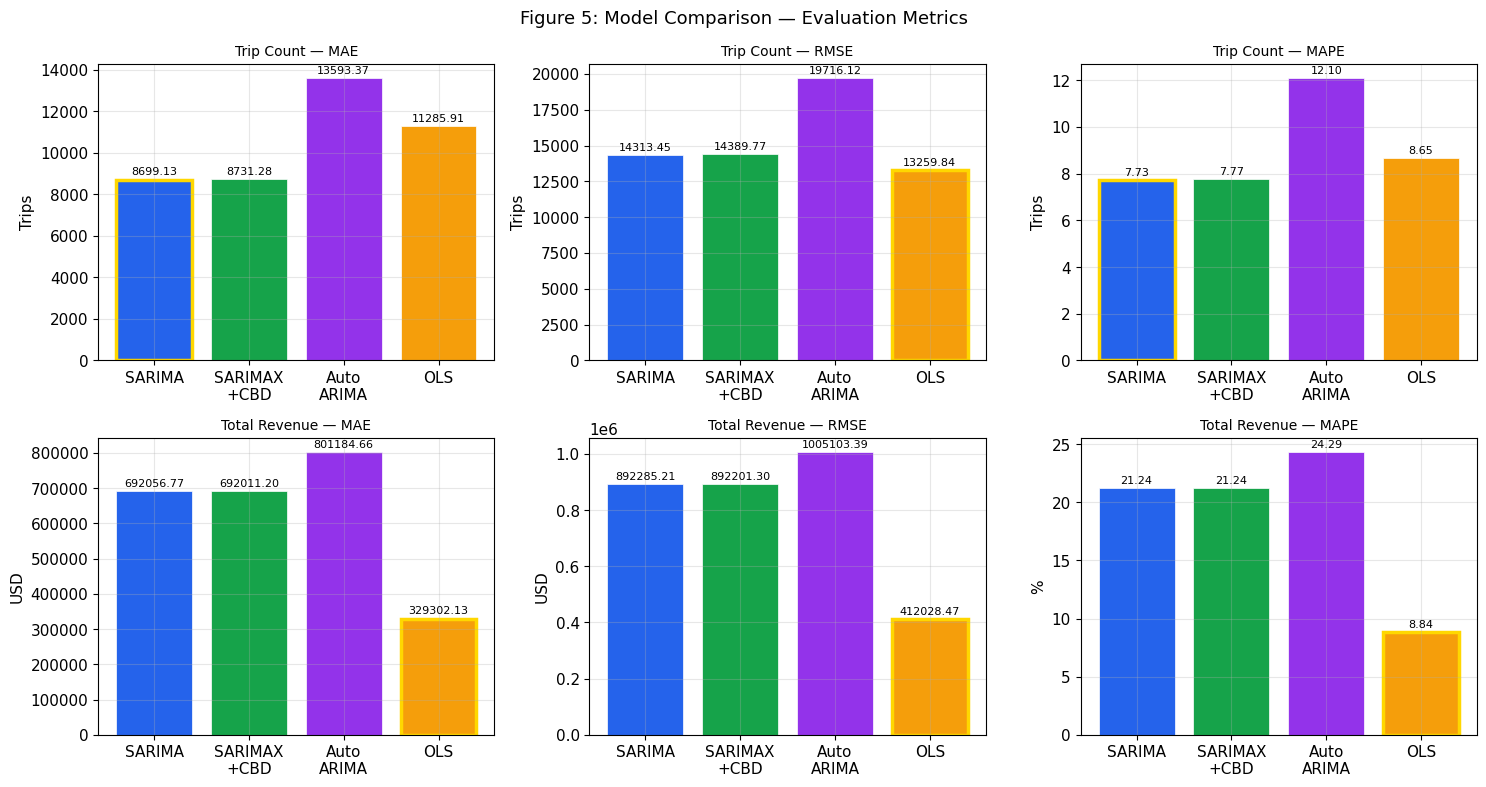

Saved: t3_fig5_metrics_barchart.png


In [13]:
# CELL 12 — Figure 5: Metrics bar chart (both targets)

model_labels = ["SARIMA", "SARIMAX\n+CBD", "Auto\nARIMA", "OLS"]
colors = ["#2563EB", "#16A34A", "#9333EA", "#F59E0B"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Figure 5: Model Comparison — Evaluation Metrics", fontsize=13)

for row, (label, results) in enumerate([
    ("Trip Count",    tc_results),
    ("Total Revenue", tr_results),
]):
    for col_idx, metric in enumerate(["MAE", "RMSE", "MAPE"]):
        ax = axes[row][col_idx]
        vals = results[metric].values
        bars = ax.bar(model_labels, vals, color=colors,
                      edgecolor="white", linewidth=0.5)
        unit = "Trips" if label == "Trip Count" else ("USD" if metric != "MAPE" else "%")
        ax.set_title(f"{label} — {metric}", fontsize=10)
        ax.set_ylabel(unit)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01 * max(vals),
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
        # Gold border on best
        bars[np.argmin(vals)].set_edgecolor("gold")
        bars[np.argmin(vals)].set_linewidth(2.5)

plt.tight_layout()
plt.savefig("/content/t3_fig5_metrics_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: t3_fig5_metrics_barchart.png")

In [15]:
# CELL 13 — Download all outputs

print("\n")
print("=" * 65)
print("  TASK 3 COMPLETE")
print("=" * 65)
print("""
Primary   target: trip_count    — 4 models fitted and evaluated
Secondary target: total_revenue — 4 models fitted and evaluated

Models per target:
  1. SARIMA(1,1,1)(1,1,1)[7]       manual order from Task 2
  2. SARIMAX(1,1,1)(1,1,1)[7]+CBD  accounts for Jan 2025 structural break
  3. Auto-ARIMA (AIC-selected)     data-driven order selection
  4. OLS Linear Regression         calendar + lag features baseline

Output files saved to /content/ and downloaded.
""")
print("=" * 65)



  TASK 3 COMPLETE

Primary   target: trip_count    — 4 models fitted and evaluated
Secondary target: total_revenue — 4 models fitted and evaluated

Models per target:
  1. SARIMA(1,1,1)(1,1,1)[7]       manual order from Task 2
  2. SARIMAX(1,1,1)(1,1,1)[7]+CBD  accounts for Jan 2025 structural break
  3. Auto-ARIMA (AIC-selected)     data-driven order selection
  4. OLS Linear Regression         calendar + lag features baseline

Output files saved to /content/ and downloaded.

